# Response-function GEA — SNP vs SV, beyond the linear LFMM

Standard LFMM tests **one** shape per locus: a monotone-linear climate/Δp relationship = **antagonistic pleiotropy / clinal** adaptation. It is blind to **intermediate optimum** (adaptive only mid-gradient → concave *hump*, linear term ≈0) and mis-specifies **conditional neutrality** (one-sided ramp). Here we basis-expand the environment (linear+quadratic, envs bio1 & bio12) at the honest **site level** (31 gardens), on the variance-stabilised **logit(p9)** scale, and calibrate every shape statistic with a **climate-permutation null** (no GIF fudge). Two weightings: `none` (OLS) and `flowers` (drift-aware ~ s-coef). Question: **are SVs enriched for curvature the linear scan misses, vs SNPs?**

In [1]:
import sys, os
PROJ='/global/scratch/users/tbellg/kmate'
sys.path.insert(0, f'{PROJ}/analysis/grenenet_gea')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib as mpl, lib
mpl.rcParams.update({'figure.dpi':110,'font.size':10,'axes.spines.top':False,'axes.spines.right':False})
SG=f'{PROJ}/results/grenenet_gea/gea_newpanel/shape_gea'
OUT=SG+'/fig'; os.makedirs(OUT, exist_ok=True)
CLS=['snp','indel','sv']; WGT=['none','flowers']
ACC={'snp':'#c1443c','indel':'#c9922e','sv':'#2e7d5b'}; NAME={'snp':'SNP','indel':'indel','sv':'SV'}
def load(cls,w):
    z=np.load(f'{SG}/shape_{cls}_{w}.npz', allow_pickle=True)
    return pd.DataFrame({k:z[k] for k in z.files})
D={(c,w):load(c,w) for c in CLS for w in WGT}
for c in CLS: print(f'{c}: {len(D[(c,"none")]):,} loci')

snp: 1,991,825 loci
indel: 664,615 loci
sv: 28,260 loci


## (1) Genome-wide shape rates — permutation p<0.05
`lin` = clinal/AP (what LFMM sees). `quad` = curvature. **`quad_only`** = curved but NOT linear (p_lin>0.5) = the response the linear GEA is blind to. `concave` = hump (intermediate optimum) share among curved.

In [2]:
rows=[]
for w in WGT:
  for c in CLS:
    d=D[(c,w)]; sig_l=d.p_lin<0.05; sig_q=d.p_quad<0.05
    qonly=sig_q & (d.p_lin>0.5)
    conc=(d.qsign_bio1<0)
    rows.append(dict(weight=w,cls=c,n=len(d),
        lin_pct=100*sig_l.mean(), quad_pct=100*sig_q.mean(),
        quad_only_pct=100*qonly.mean(),
        concave_of_quad_pct=100*(sig_q&conc).sum()/max(sig_q.sum(),1)))
tab=pd.DataFrame(rows); pd.set_option('display.float_format',lambda x:f'{x:.2f}')
tab

,weight,cls,n,lin_pct,quad_pct,quad_only_pct,concave_of_quad_pct
0,none,snp,1991825,11.28,5.02,2.24,31.40
1,none,indel,664615,11.53,4.91,2.18,30.78
2,none,sv,28260,12.18,5.05,2.03,36.69
3,flowers,snp,1991825,2.88,4.11,3.29,21.26
4,flowers,indel,664615,2.88,4.23,3.39,20.33
5,flowers,sv,28260,2.96,3.52,2.70,23.24


## (2) Frequency-matched curvature enrichment — SV & indel vs SNP
Curvature rate depends on the MAF/p0 spectrum, and SVs and SNPs differ there. So we **match on p0**: for each SV (indel) locus draw a SNP of nearest p0, and compare the `quad`-hit and `quad_only`-hit rates. Bootstrap over loci → 95% CI on the SV/SNP rate ratio. A ratio CI above 1 = SVs genuinely carry more curvature than frequency-matched SNPs.

In [3]:
rng=np.random.default_rng(0)
def matched_snp_idx(p0_target, p0_snp, k=1):
    order=np.argsort(p0_snp); ps=p0_snp[order]
    j=np.searchsorted(ps, p0_target)
    j=np.clip(j,0,len(ps)-1); return order[j]
def enrich(cls, w, nboot=500):
    dv=D[(cls,w)]; ds=D[('snp',w)]
    p0s=ds.p0.to_numpy()
    mi=matched_snp_idx(dv.p0.to_numpy(), p0s)
    def rates(mask_v, mask_s):
        return mask_v.mean(), mask_s.mean()
    out={}
    for key,fn in [('quad',lambda d:(d.p_quad<0.05).to_numpy()),
                   ('quad_only',lambda d:((d.p_quad<0.05)&(d.p_lin>0.5)).to_numpy())]:
        mv=fn(dv); ms=fn(ds)[mi]
        rv,rs=mv.mean(),ms.mean(); ratio=rv/max(rs,1e-9)
        bs=[]
        n=len(mv)
        for _ in range(nboot):
            b=rng.integers(0,n,n); bs.append(mv[b].mean()/max(ms[b].mean(),1e-9))
        lo,hi=np.percentile(bs,[2.5,97.5])
        out[key]=dict(rate_v=100*rv,rate_snp=100*rs,ratio=ratio,lo=lo,hi=hi)
    return out
erows=[]
for w in WGT:
  for cls in ['indel','sv']:
    e=enrich(cls,w)
    for key in ['quad','quad_only']:
        r=e[key]; erows.append(dict(weight=w,cls=cls,stat=key,
            rate_pct=r['rate_v'],matched_snp_pct=r['rate_snp'],
            ratio=r['ratio'],ci=f"[{r['lo']:.2f},{r['hi']:.2f}]"))
enr=pd.DataFrame(erows); enr

,weight,cls,stat,rate_pct,matched_snp_pct,ratio,ci
0,none,indel,quad,4.91,4.97,0.99,"[0.97,1.00]"
1,none,indel,quad_only,2.18,2.23,0.98,"[0.96,1.00]"
2,none,sv,quad,5.05,4.73,1.07,"[1.00,1.14]"
3,none,sv,quad_only,2.03,2.01,1.01,"[0.91,1.13]"
4,flowers,indel,quad,4.23,4.17,1.01,"[1.00,1.03]"
5,flowers,indel,quad_only,3.39,3.39,1.00,"[0.99,1.02]"
6,flowers,sv,quad,3.52,3.74,0.94,"[0.87,1.01]"
7,flowers,sv,quad_only,2.70,2.94,0.92,"[0.85,1.00]"


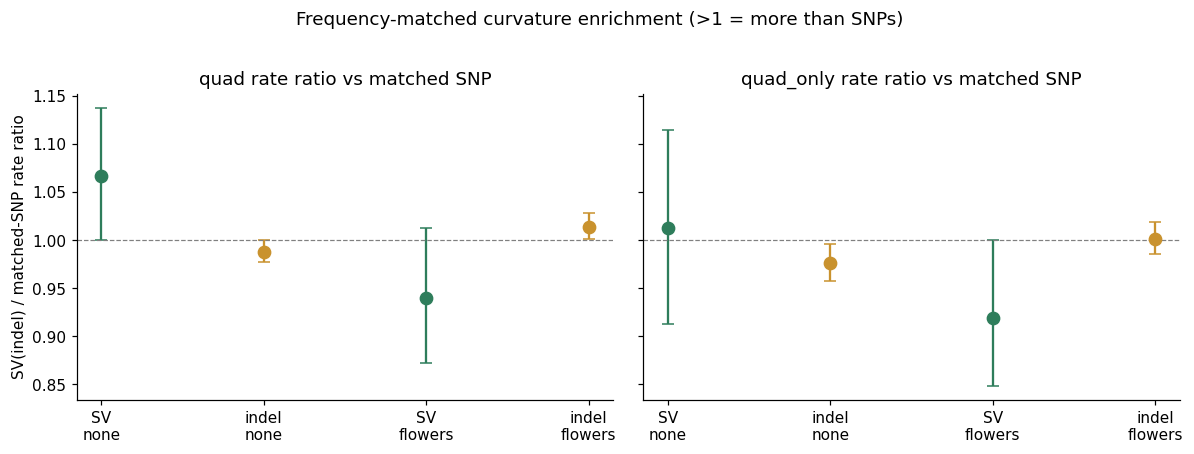

In [4]:
# plot the frequency-matched ratio + CI (SV & indel vs matched SNP), both weightings
fig,axes=plt.subplots(1,2,figsize=(11,4),sharey=True)
for ax,key in zip(axes,['quad','quad_only']):
    ys=[]; labs=[]; i=0
    for w in WGT:
      for cls in ['sv','indel']:
        e=enrich(cls,w)[key]
        ax.errorbar(i,e['ratio'],yerr=[[e['ratio']-e['lo']],[e['hi']-e['ratio']]],
            fmt='o',ms=8,color=ACC[cls],capsize=4)
        labs.append(f'{NAME[cls]}\n{w}'); i+=1
    ax.axhline(1,ls='--',lw=0.8,color='0.5')
    ax.set_xticks(range(i)); ax.set_xticklabels(labs); ax.set_title(f'{key} rate ratio vs matched SNP')
axes[0].set_ylabel('SV(indel) / matched-SNP rate ratio')
fig.suptitle('Frequency-matched curvature enrichment (>1 = more than SNPs)',y=1.02)
fig.tight_layout(); fig.savefig(f'{OUT}/curvature_enrichment.png',dpi=150,bbox_inches='tight'); plt.show()

## (3) Response-shape class mix — SNP vs indel vs SV (frequency-matched)
Classify each locus: **none** (no shape), **linear/AP** (lin only), **hump/interm-opt** (quad sig, concave), **valley/disruptive** (quad sig, convex), **both**. SNP set is p0-matched to the SV set so the mix is comparable.

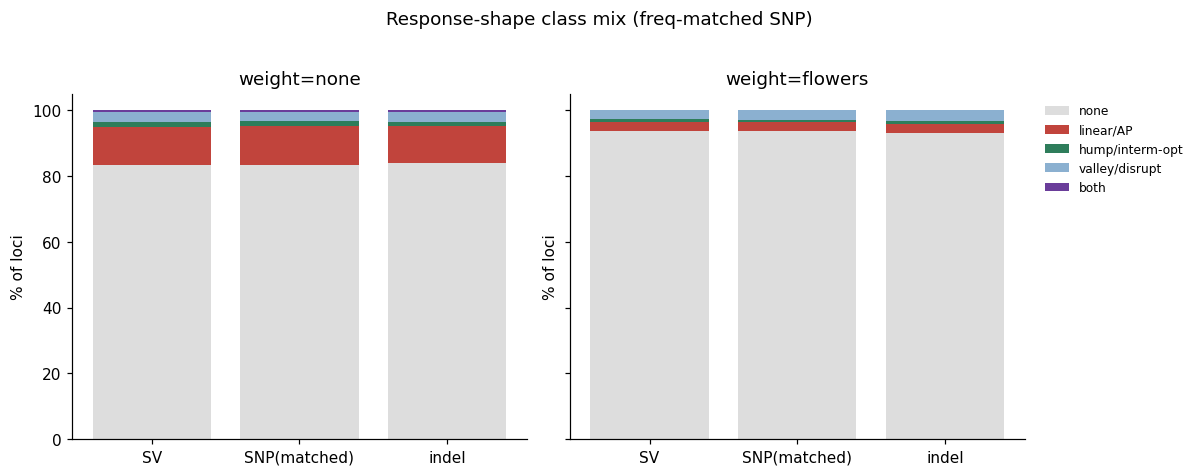

In [5]:
def classify(d):
    sl=d.p_lin<0.05; sq=d.p_quad<0.05; conc=d.qsign_bio1<0
    cl=np.full(len(d),'none',object)
    cl[sl&~sq]='linear/AP'
    cl[sq&conc]='hump/interm-opt'
    cl[sq&~conc]='valley/disrupt'
    cl[sl&sq]='both'
    return pd.Series(cl)
ORD=['none','linear/AP','hump/interm-opt','valley/disrupt','both']
COLC={'none':'#dddddd','linear/AP':'#c1443c','hump/interm-opt':'#2e7d5b','valley/disrupt':'#8bb0d0','both':'#6a3d9a'}
fig,axes=plt.subplots(1,2,figsize=(11,4.2),sharey=True)
for ax,w in zip(axes,WGT):
    dsv=D[('sv',w)]; dsn=D[('snp',w)]
    mi=matched_snp_idx(dsv.p0.to_numpy(), dsn.p0.to_numpy())
    mats={'SV':classify(dsv),'SNP(matched)':classify(dsn.iloc[mi].reset_index(drop=True)),
          'indel':classify(D[('indel',w)])}
    labels=list(mats); bottom=np.zeros(len(labels))
    for k in ORD:
        vals=np.array([ (m==k).mean()*100 for m in mats.values()])
        ax.bar(labels,vals,bottom=bottom,color=COLC[k],label=k); bottom+=vals
    ax.set_title(f'weight={w}'); ax.set_ylabel('% of loci')
axes[1].legend(bbox_to_anchor=(1.02,1),loc='upper left',fontsize=8,frameon=False)
fig.suptitle('Response-shape class mix (freq-matched SNP)',y=1.02)
fig.tight_layout(); fig.savefig(f'{OUT}/shape_class_mix.png',dpi=150,bbox_inches='tight'); plt.show()

## (4) Curvature Manhattan — where the intermediate-optimum hits land
F_quad per locus, SNP (top) vs SV (bottom). Highlighted = **quad_only** (curved, linear-blind). These are candidate loci a standard LFMM would never flag.

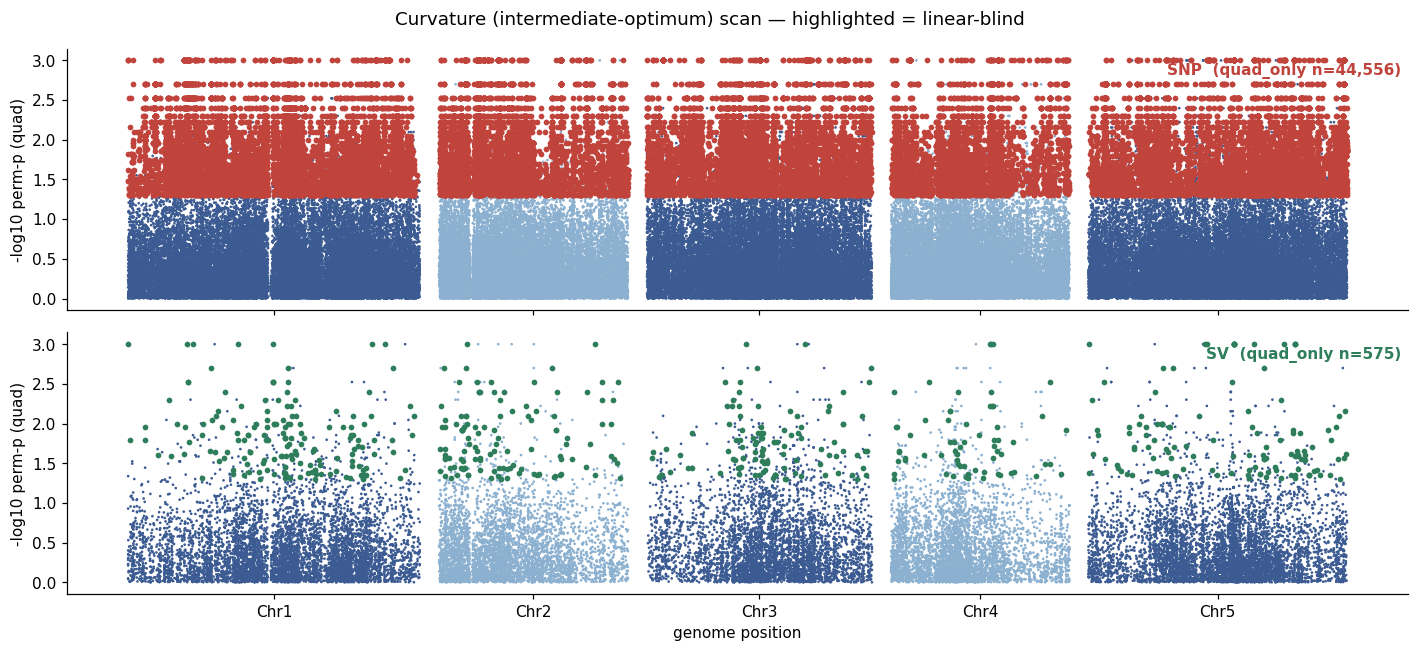

In [6]:
CHR=[f'Chr{i}' for i in range(1,6)]
off={}; run=0
allpos={c:max(D[(cl,'none')].loc[D[(cl,'none')].chrom==c,'pos'].max() for cl in CLS) for c in CHR}
for c in CHR: off[c]=run; run+=int(allpos[c])+int(2e6)
ticks=[off[c]+allpos[c]/2 for c in CHR]
cols={'Chr1':'#3b5b92','Chr2':'#8bb0d0','Chr3':'#3b5b92','Chr4':'#8bb0d0','Chr5':'#3b5b92'}
w='none'
fig,axes=plt.subplots(2,1,figsize=(13,6),sharex=True)
for ax,cls in zip(axes,['snp','sv']):
    d=D[(cls,w)].copy(); d['gx']=d.pos.astype(float)+d.chrom.map(off)
    d['nlq']=-np.log10(d.p_quad.clip(1e-4))
    qonly=(d.p_quad<0.05)&(d.p_lin>0.5)
    base=d[~qonly].sample(frac=min(1.0,200000/len(d)),random_state=0)
    ax.scatter(base.gx,base.nlq,s=3,c=base.chrom.map(cols),rasterized=True,linewidths=0)
    ax.scatter(d.gx[qonly],d.nlq[qonly],s=14,color=ACC[cls],linewidths=0,zorder=5)
    ax.set_ylabel('-log10 perm-p (quad)')
    ax.text(0.995,0.9,f'{NAME[cls]}  (quad_only n={int(qonly.sum()):,})',transform=ax.transAxes,
            ha='right',fontweight='bold',color=ACC[cls])
axes[1].set_xticks(ticks); axes[1].set_xticklabels(CHR); axes[1].set_xlabel('genome position')
fig.suptitle('Curvature (intermediate-optimum) scan — highlighted = linear-blind',y=0.98)
fig.tight_layout(); fig.savefig(f'{OUT}/curvature_manhattan.png',dpi=150,bbox_inches='tight'); plt.show()

## (5) Top linear-blind curved SV loci — annotated
SVs with strong curvature (low perm-p_quad) but NO linear signal (p_lin>0.5): the SV response functions a standard climate-GEA cannot see. Gene = TAIR10 ±2 kb.

In [7]:
genes=lib.load_genes(); w='none'
d=D[('sv',w)].copy()
cand=d[(d.p_lin>0.5)].nsmallest(30,'p_quad').copy()
cand['shape']=np.where(cand.qsign_bio1<0,'hump(interm-opt)','valley(disrupt)')
cand['ref_len']=1; cand['alt_len']=1+cand.sv_size  # for annotate_svs flank logic
a=lib.annotate_svs(cand.rename(columns={}).copy(),flank=2000,genes=genes)
cand['gene_name']=a.gene_name.values; cand['genes']=a.genes_all.values
keep=['chrom','pos','sv_size','maf','p0','p_lin','p_quad','p_full','shape','gene_name','genes']
cand=cand[keep].reset_index(drop=True)
cand.to_csv(f'{SG}/fig/top_curved_sv_linear_blind_annotated.csv',index=False)
pd.set_option('display.width',220,'display.max_colwidth',36); cand.head(25)

,chrom,pos,sv_size,maf,p0,p_lin,p_quad,p_full,shape,gene_name,genes
0,Chr1,105,151,0.06,0.03,0.65,0.00,0.00,valley(disrupt),,
1,Chr1,6156401,2472,0.20,0.71,0.89,0.00,0.00,hump(interm-opt),AT1G17890,AT1G17890
2,Chr1,6759616,58,0.48,0.51,0.57,0.00,0.00,valley(disrupt),AT1G19520,AT1G19520
3,Chr1,11461853,67,0.06,0.89,0.87,0.00,0.00,hump(interm-opt),AT1G31910,AT1G31910;AT1G31920
4,Chr1,15096421,479,0.14,0.75,0.64,0.00,0.00,hump(interm-opt),,
5,Chr1,25433884,127,0.06,0.11,0.82,0.00,0.01,valley(disrupt),AT1G67830,AT1G67830;AT1G67840
6,Chr1,26779628,63,0.08,0.14,0.67,0.00,0.01,valley(disrupt),,
7,Chr2,2885876,157,0.07,0.12,0.85,0.00,0.01,valley(disrupt),,
8,Chr2,16302458,73,0.05,0.08,0.64,0.00,0.00,valley(disrupt),AT2G39040,AT2G39040;AT2G39050
9,Chr3,10353570,1477,0.18,0.20,0.54,0.00,0.00,valley(disrupt),AT3G27890,AT3G27890;AT3G27900;AT3G27906


## (6) Weighting agreement — OLS vs drift-aware (flowers)
Do the curved-SV calls survive drift-weighting? Overlap of `quad`-hit SV sets between `none` and `flowers`. Robust hits appear in both.

In [8]:
for cls in CLS:
    a=(D[(cls,'none')].p_quad<0.05).to_numpy(); b=(D[(cls,'flowers')].p_quad<0.05).to_numpy()
    jac=(a&b).sum()/max((a|b).sum(),1)
    print(f'{cls}: quad-hit none={a.sum():,} flowers={b.sum():,} both={(a&b).sum():,} Jaccard={jac:.3f}')

snp: quad-hit none=99,927 flowers=81,809 both=40,117 Jaccard=0.283
indel: quad-hit none=32,609 flowers=28,103 both=13,409 Jaccard=0.283
sv: quad-hit none=1,428 flowers=994 both=534 Jaccard=0.283


### Read-out
- **(1)** quad-hit rate near ~5% genome-wide = permutation null is calibrated; the signal is in the SNP-vs-SV **difference**, not the absolute rate.
- **(2)** is the headline: freq-matched SV/SNP curvature ratio with CI. Ratio CI >1 = SVs carry non-linear climate responses beyond what MAF explains — and `quad_only` isolates the part a linear LFMM is blind to.
- **(3)** the shape-class mix shows whether SVs skew toward hump (intermediate optimum) vs the SNP linear/AP mode.
- **(5)** names the candidate linear-blind SV loci; **(6)** checks they survive drift-weighting.
- Caveat: 31 sites → low per-locus power; this is a **class-distribution** claim (are SVs *enriched* for curvature), not per-locus discovery.